# Rete custom
## Caricamento dati


In [126]:
import os 
import cv2
import pathlib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
dataset_dir = '/kaggle/input/datasets/francescospecchia/fives-duplicates'

#print("Current dir: ", os.getcwd())
#input_path = '/kaggle/input/datasets/francescospecchia/fives-duplicates'
#available_datasets = os.listdir(input_path)
#print("Available datasets:", available_datasets)

#dataset_dir = '../FIVES'
train_dir = pathlib.Path(dataset_dir) / 'train/Original'
test_dir = pathlib.Path(dataset_dir) / 'test/Original'

In [128]:
seed = 42
epochs = 500
batch_size = 16
img_size = (2048, 2048)
img_shrinked = (512,512)

In [129]:
def create_dataframe(data_dir):
    filepaths = []
    labels = []
    
    for filename in os.listdir(data_dir):
        if filename.endswith('.png'):
            filepath = os.path.join(data_dir, filename)
            
            # Extract class from filename (format: "121_G.png")
            # Assuming the class is the character after the underscore
            class_name = filename.split('_')[1].split('.')[0]  # Gets 'G' from '121_G.png'
            
            filepaths.append(filepath)
            labels.append(class_name)
    
    return pd.DataFrame({'filepath': filepaths, 'class': labels})

path_n_classes_df = create_dataframe(train_dir)

In [ ]:
# Adds a black box to cover the chinese character on top left corner of an image
# And equalizes the histogram of the image
def mask_character(img):

    img[:60, :60] = 0
    
    # Normalize to uint8 for OpenCV
    orig_dtype = img.dtype
    if orig_dtype != np.uint8:
        if img.max() <= 1.0:
            img_u8 = (img).astype(np.uint8)
        else:
            img_u8 = img.astype(np.uint8)
    else:
        img_u8 = img


    # Ensure 3 channels
    if img_u8.ndim == 2:
        img_u8 = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB)

    # RGB -> BGR -> LAB
    bgr = cv2.cvtColor(img_u8, cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to L channel (uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # Merge and convert back to RGB
    lab = cv2.merge((l, a, b))
    bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # Return in the same value range expected by caller
    if orig_dtype == np.uint8:
        return rgb
    else:
        return (rgb.astype(np.float32))


In [ ]:
train_df, val_df = train_test_split(
    path_n_classes_df, 
    test_size=0.2, 
    stratify=path_n_classes_df['class'],
    random_state=seed
)

# Create data generators
datagen_train = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=False, #provo a settare false perché potrebbe non aiutare confondere occhio dx e sx
    preprocessing_function=mask_character,
    zoom_range=0.1,
    width_shift_range=0.09,
    height_shift_range=0.09,
)


datagen_val = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=mask_character
)


train_generator = datagen_train.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='class',
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_generator = datagen_val.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='class',
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 480 validated image filenames belonging to 4 classes.


Found 120 validated image filenames belonging to 4 classes.


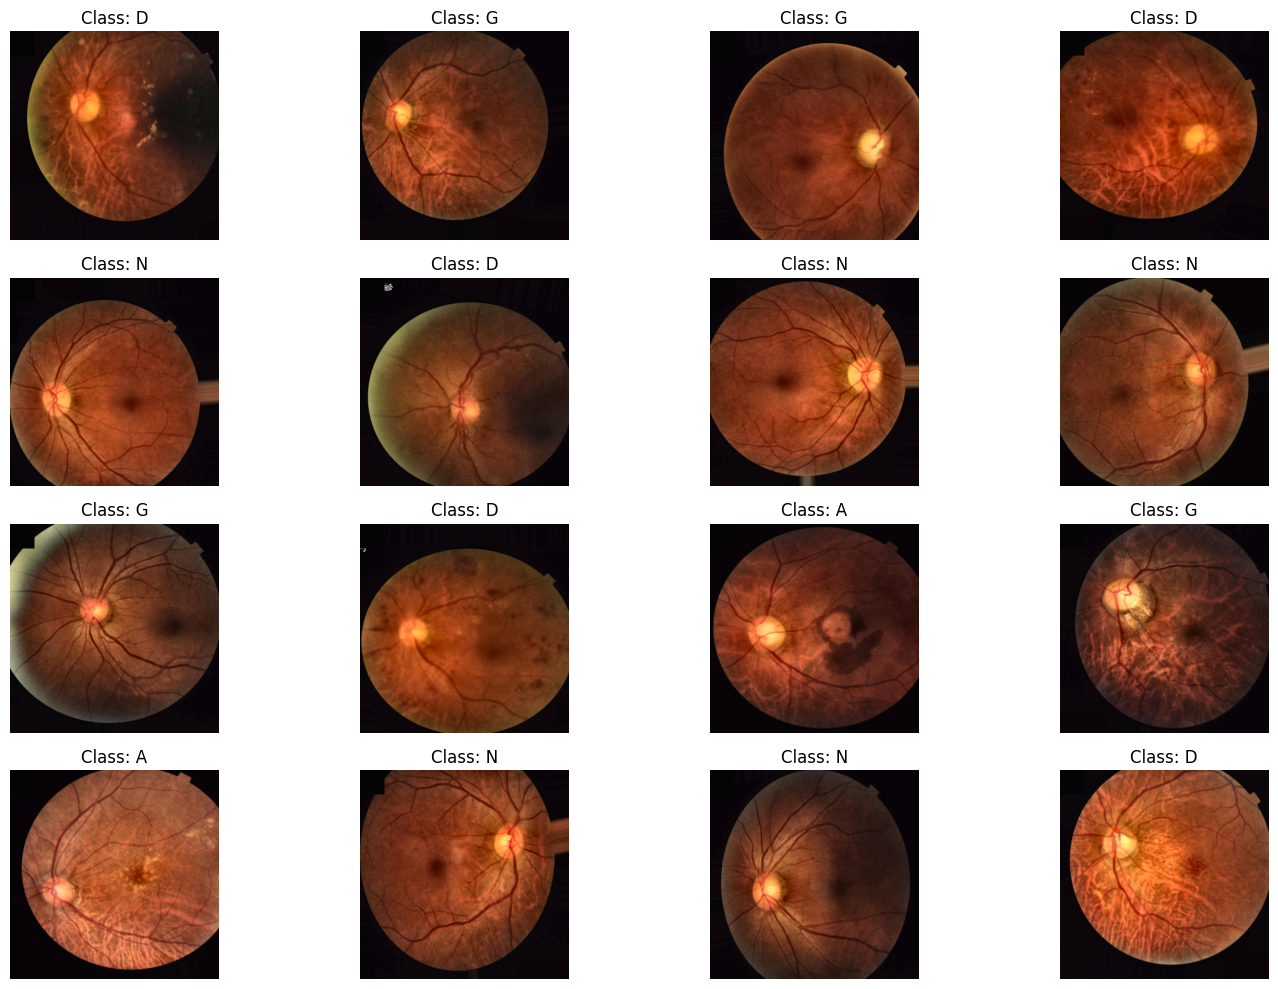

In [132]:
# Prendi un batch
images, labels = next(train_generator)

# Configura la visualizzazione
plt.figure(figsize=(15, 10))

# Ottieni i nomi delle classi
class_names = list(train_generator.class_indices.keys())

# Mostra fino a 16 immagini (o quante ne hai nel batch)
num_images = min(16, len(images))

for i in range(num_images):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i] )
    
    # Trova la classe (per one-hot encoded labels)
    class_idx = np.argmax(labels[i])
    class_name = class_names[class_idx]
    
    plt.title(f"Class: {class_name}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Definizione del modello

In [82]:
# Monitor F1 score
from sklearn.metrics import f1_score
class F1Callback(tf.keras.callbacks.Callback):
    def __init__(self, x_val, y_val, average="macro"):
        super().__init__()
        self.x_val = x_val
        self.y_val = np.argmax(y_val, axis=1)  
        self.average = average
        self.val_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(self.x_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        f1 = f1_score(
            self.y_val,
            y_pred,
            average=self.average
        )

        self.val_f1.append(f1)
        print(f" - val_f1: {f1:.4f}")

        if logs is not None:
            logs["val_f1"] = f1

In [6]:
img_shape = img_shrinked + (3, )
img_shape

(512, 512, 3)

In [ ]:
# SE attention block
def se_block(x, ratio=16):

    filters = x.shape[-1]

    se = tf.keras.layers.GlobalAveragePooling2D()(x)

    se = tf.keras.layers.Dense(filters // ratio,
               activation='leaky_relu')(se)

    se = tf.keras.layers.Dense(filters,
               activation='sigmoid')(se)

    se = tf.keras.layers.Reshape((1,1,filters))(se)

    return tf.keras.layers.Multiply()([x, se])

def residual_block(x, filters):

    shortcut = x

    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.LeakyReLU()(x)

    return x

def residual_downsample_block(x, filters):

    shortcut = tf.keras.layers.Conv2D(
        filters,
        kernel_size=1,
        strides=2,
        padding='same'
    )(x)

    shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        strides=2,
        padding='same'
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding='same'
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.activations.leaky_relu(x)

    return x

def encoder(inputs):

    x = tf.keras.layers.Conv2D(32, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = se_block(x)

    x = residual_downsample_block(x, 64)
    x = residual_block(x, 64)
    x = se_block(x)

    x = residual_downsample_block(x, 128)
    x = residual_block(x, 128)
    x = se_block(x)

    x = residual_downsample_block(x, 256)
    x = residual_block(x, 256)
    x = se_block(x)

    x = residual_downsample_block(x, 512)
    x = residual_block(x, 512)
    x = se_block(x)

    #x = residual_downsample_block(x, 1024)
    #x = residual_block(x, 1024)
    #x = se_block(x)

    return x

def create_model(inputs):
    x = encoder(inputs)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.activations.gelu(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

In [22]:
model = create_model(tf.keras.Input(shape=img_shape))
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_117 (Conv2D) │ (None, 512, 512,  │        896 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_117[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_57      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_118 (Conv2D) │ (None, 512, 512,  │      9,248 │ leaky_re_lu_57[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_118[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_58      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_119 (Conv2D) │ (None, 512, 512,  │      9,248 │ leaky_re_lu_58[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_119[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_33 (Add)        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ leaky_re_lu_57[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_59      │ (None, 512, 512,  │          0 │ add_33[0][0]      │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_120 (Conv2D) │ (None, 512, 512,  │      9,248 │ leaky_re_lu_59[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_120[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_60      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_121 (Conv2D) │ (None, 512, 512,  │      9,248 │ leaky_re_lu_60[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_121[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_34 (Add)        │ (None, 512, 512,  │          0 │ batch_normalizat

 Total params: 11,380,706 (43.41 MB)

 Trainable params: 11,370,786 (43.38 MB)

 Non-trainable params: 9,920 (38.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-5, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

In [ ]:
# Extract validation data from generator to use with F1Callback
x_val = []
y_val = []

validation_generator.reset()
for i in range(len(validation_generator)):
    images, labels = validation_generator[i]
    x_val.append(images)
    y_val.append(labels)

x_val = np.concatenate(x_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

print(f"Validation data shape: {x_val.shape}")
print(f"Validation labels shape: {y_val.shape}")

In [ ]:
# Calculate f1 on validation set at the end of each epoch
f1_callback = F1Callback(x_val, y_val, average="macro")

# Early stopping on validation f1
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_f1', 
    patience=35,  
    mode='max', 
    restore_best_weights=True,
    start_from_epoch=30,
)

# Scheduler
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_f1',
    mode='max',
    patience=8,
    factor=0.5,
    min_lr=1e-7
)

In [ ]:


history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[f1_callback, early_stopping, reduce_lr],
)

In [ ]:
plt.figure(figsize = (10,7))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy') 
plt.plot(f1_callback.val_f1, label="validation f1")


plt.legend()  
plt.ylim([0,1]) 
#plt.xticks(range(0,n_epochs))
plt.yticks(np.array(range(10))/10)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Batch size: {batch_size}')
plt.grid('both', linestyle='--')
plt.tight_layout()
plt.savefig(f'acmonides_accuracy_bs{batch_size}.pdf')

In [ ]:
plt.figure(figsize = (10,7))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='validation loss') 

plt.legend()  
#plt.xticks(range(0,n_epochs))
plt.semilogy()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Batch size: {batch_size}')
plt.grid('both', linestyle='--')
plt.tight_layout()
plt.savefig(f'acmonides_loss_bs{batch_size}.pdf')

## Performance on test set

In [ ]:
test_df = create_dataframe(test_dir)
test_df

In [ ]:
datagen_test = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=mask_character
)

test_generator = datagen_test.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='class',
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

In [ ]:
test_pred = model.predict(test_generator)
print(test_pred.shape)
pred_labels = np.argmax(test_pred, axis = 1)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sn

# true labels
true_labels = np.array(test_generator.classes)
class_labels = ['A', 'D', 'G', 'N']

#print(true_labels)
#print(pred_labels)
# accuracy
acc = accuracy_score(true_labels, pred_labels)

print(f"Test Accuracy: {acc:.4f}")

cm = confusion_matrix(true_labels, pred_labels, normalize='pred')
df_cm = pd.DataFrame(cm, index = [i for i in class_labels],
                  columns = [i for i in class_labels])
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True)
plt.title("Confusion Matrix")
plt.tight_layout()


In [ ]:
class_labels = ['A', 'D', 'G', 'N']

grad_inputs = tf.keras.Input(shape=img_shape)
feature_maps = encoder(grad_inputs)
x = model.layers[-3](feature_maps)
x = model.layers[-2](x)
grad_predictions = model.layers[-1](x)

grad_model = tf.keras.Model(
    inputs=grad_inputs,
    outputs=[feature_maps, grad_predictions]
)

def make_gradcam_heatmap(img_array, grad_model, pred_index=None):
    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        pred_index = int(pred_index)
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, feature_maps)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    feature_maps = feature_maps[0]

    heatmap = tf.reduce_sum(feature_maps * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
    return heatmap.numpy()

def load_image_for_gradcam(filepath):
    image = tf.keras.utils.load_img(filepath, target_size=img_shrinked)
    image_array = tf.keras.utils.img_to_array(image)
    image_array = mask_character(image_array)
    image_array = image_array / 255.0
    return image_array

def get_eval_dataframe(split='test'):
    if split == 'test':
        return test_df
    if split == 'train':
        return create_dataframe(train_dir)
    raise ValueError("split must be either 'test' or 'train'")

def plot_random_gradcams(split='test', n_samples=6, seed=42):
    eval_df = get_eval_dataframe(split)
    rng = np.random.default_rng(seed)
    n_samples = min(n_samples, len(eval_df))
    sample_indices = rng.choice(len(eval_df), size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 2, figsize=(10, 4 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(sample_indices):
        filepath = eval_df.iloc[idx]['filepath']
        true_label = eval_df.iloc[idx]['class']

        image_array = load_image_for_gradcam(filepath)
        batch = np.expand_dims(image_array, axis=0)

        predictions = model.predict(batch, verbose=0)[0]
        pred_index = int(np.argmax(predictions))
        heatmap = make_gradcam_heatmap(batch, grad_model, pred_index=pred_index)

        axes[row, 0].imshow(image_array)
        axes[row, 0].set_title(f'{split.title()} true: {true_label}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(image_array)
        axes[row, 1].imshow(heatmap, cmap='jet', alpha=0.45)
        axes[row, 1].set_title(
            f'{split.title()} pred: {class_labels[pred_index]} ({predictions[pred_index]:.2f})'
        )
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

#plot_random_gradcams(split='test', n_samples=10, seed=14)
# To visualize training samples instead, run:
plot_random_gradcams(split='train', n_samples=10, seed=seed)

In [ ]:
plot_random_gradcams(split='test', n_samples=10, seed=seed)

In [ ]:
model.save(f'acmonides_{acc:.4f}.keras')